# Neuroevolution on EvoGym

## Getting started

Check that the following line can run. If so, you have evogym installed! Otherwise, you need to install it.

In [152]:
from evogym import sample_robot
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
import matplotlib.pyplot as plt
from matplotlib import animation
import gymnasium as gym
import evogym.envs
from evogym import sample_robot
from evogym.utils import get_full_connectivity
from tqdm import tqdm
import json
import time
import imageio

## Agent

In [153]:
class Network(nn.Module):
    def __init__(self, n_in, h_size, n_out):
        super().__init__()
        self.fc1 = nn.Linear(n_in, h_size)
        self.fc2 = nn.Linear(h_size, h_size)
        self.fc3 = nn.Linear(h_size, n_out)
 
        self.n_out = n_out

    def reset(self):
        pass
    
    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)

        x = self.fc2(x)
        x = F.relu(x)

        x = self.fc3(x)
        return x

In [154]:
class Agent:
    def __init__(self, Net, config, genes = None):
        self.config = config
        self.Net = Net
        self.model = None
        self.fitness = None

        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu")

        self.make_network()
        if genes is not None:
            self.genes = genes

    def __repr__(self):  # pragma: no cover
        return f"Agent {self.model} > fitness={self.fitness}"

    def __str__(self):  # pragma: no cover
        return self.__repr__()

    def make_network(self):
        n_in = self.config["n_in"]
        h_size = self.config["h_size"]
        n_out = self.config["n_out"]
        self.model = self.Net(n_in, h_size, n_out).to(self.device).double()
        return self

    @property
    def genes(self):
        if self.model is None:
            return None
        with torch.no_grad():
            params = self.model.parameters()
            vec = torch.nn.utils.parameters_to_vector(params)
        return vec.cpu().double().numpy()

    @genes.setter
    def genes(self, params):
        if self.model is None:
            self.make_network()
        assert len(params) == len(
            self.genes), "Genome size does not fit the network size"
        if np.isnan(params).any():
            raise
        a = torch.tensor(params, device=self.device)
        torch.nn.utils.vector_to_parameters(a, self.model.parameters())
        self.model = self.model.to(self.device).double()
        self.fitness = None
        return self

    def mutate_ga(self):
        genes = self.genes
        n = len(genes)
        f = np.random.choice([False, True], size=n, p=[1/n, 1-1/n])
        
        new_genes = np.empty(n)
        new_genes[f] = genes[f]
        noise = np.random.randn(n-sum(f))
        new_genes[~f] = noise
        return new_genes

    def act(self, obs):
        # continuous actions
        with torch.no_grad():
            x = torch.tensor(obs).double().unsqueeze(0).to(self.device)
            actions = self.model(x).cpu().detach().numpy()
        return actions


## Environment

In [155]:
walker = np.array([
    [3, 3, 3, 3, 3],
    [3, 3, 3, 3, 3],
    [3, 0, 0, 0, 3],
    [3, 0, 0, 0, 3],
    [3, 0, 0, 0, 3]
    ])

In [156]:
def make_env(env_name, seed=None, robot=None, **kwargs):
    if robot is None: 
        env = gym.make(env_name)
    else:
        connections = get_full_connectivity(robot)
        env = gym.make(env_name, body=robot)
    env.robot = robot
    if seed is not None:
        env.seed(seed)
        
    return env

In [ ]:
def evaluate(agent, env, max_steps=500, render=False):
    obs, i = env.reset()
    agent.model.reset()
    reward = 0
    steps = 0
    done = False
    
    obs_list = []
    
    while not done and steps < max_steps:
        if render:
            env.render()
        obs_list.append(obs.copy())
        #action = agent.act(obs)
        #action = env.action_space.sample() ###Tire aleatoirement une action
        obs, r, done, trunc, _ = env.step(action)
        reward += r
        steps += 1
    return reward, np.array(obs_list)

In [158]:
def get_cfg(env_name, robot=None):
    env = make_env(env_name, robot=walker)
    cfg = {
        "n_in": env.observation_space.shape[0],
        "h_size": 32,
        "n_out": env.action_space.shape[0],
    }
    env.close()
    return cfg

In [159]:
env_name = 'Walker-v0'
robot = walker

cfg = get_cfg(env_name, robot)
a = Agent(Network, cfg)
a

Agent Network(
  (fc1): Linear(in_features=62, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
) > fitness=None

In [160]:
env = make_env(env_name, robot=walker)
s = env.reset()
len(s), s

(2,
 (array([ 0.  ,  0.  , -0.25, -0.15, -0.25, -0.15, -0.05, -0.05,  0.05,
          0.05,  0.15,  0.15,  0.25,  0.25, -0.25, -0.15, -0.05,  0.05,
          0.15,  0.25, -0.25, -0.15,  0.15,  0.25, -0.25, -0.15,  0.15,
          0.25, -0.25, -0.15,  0.15,  0.25,  0.22,  0.22,  0.12,  0.12,
          0.22,  0.12,  0.22,  0.12,  0.22,  0.12,  0.22,  0.12,  0.02,
          0.02,  0.02,  0.02,  0.02,  0.02, -0.08, -0.08, -0.08, -0.08,
         -0.18, -0.18, -0.18, -0.18, -0.28, -0.28, -0.28, -0.28]),
  {}))

In [161]:
# Evaluation
env = make_env(env_name, robot=walker)
reward, obs_list = evaluate(a, env, render=True)
print(f"Reward: {reward}")
env.close()

Reward: 0.007360093625775832


In [162]:
def mp_eval(a, cfg):
    env = make_env(cfg["env_name"], robot=cfg["robot"])
    fit, _ = evaluate(a, env, max_steps=cfg["max_steps"])
    env.close()
    return fit

### Evolution Strategy

In [163]:
def ES(config):
    cfg = get_cfg(config["env_name"], robot=config["robot"]) # Get network dims
    cfg = {**config, **cfg} # Merge configs
    
    # Update weights
    mu = cfg["mu"]
    w = np.array([np.log(mu + 0.5) - np.log(i)
                          for i in range(1, mu + 1)])
    w /= np.sum(w)
    
    env = make_env(cfg["env_name"], robot=cfg["robot"])

    # Center of the distribution
    elite = Agent(Network, cfg)
    elite.fitness = -np.inf
    theta = elite.genes
    d = len(theta)

    fits = []
    total_evals = []

    bar = tqdm(range(cfg["generations"]))
    for gen in bar:
        population = []
        for i in range(cfg["lambda"]):
            genes = theta + np.random.randn(len(theta)) * cfg["sigma"]
            ind = Agent(Network, cfg, genes=genes)
            # ind.fitness = evaluate(ind, env, max_steps=cfg["max_steps"])
            population.append(ind)

        # with Pool(processes=len(population)) as pool:
        #     pop_fitness = pool.starmap(mp_eval, [(a, cfg) for a in population])
        
        pop_fitness = [evaluate(a, env, max_steps=cfg["max_steps"])[0] for a in population]
        
        for i in range(len(population)):
            population[i].fitness = pop_fitness[i]

        # sort by fitness
        inv_fitnesses = [- f for f in pop_fitness]
        # indices from highest fitness to lowest
        idx = np.argsort(inv_fitnesses)
        
        step = np.zeros(d)
        for i in range(mu):
            # update step
            step = step + w[i] * (population[idx[i]].genes - theta)
        # update theta
        theta = theta + step * cfg["lr"]

        if pop_fitness[idx[0]] > elite.fitness:
            elite.genes = population[idx[0]].genes
            elite.fitness = pop_fitness[idx[0]]

        fits.append(elite.fitness)
        total_evals.append(len(population) * (gen+1))

        bar.set_description(f"Best: {elite.fitness}")
        
    env.close()
    plt.plot(total_evals, fits)
    plt.xlabel("Evaluations")
    plt.ylabel("Fitness")
    plt.show()
    return elite

Best: 0.0097830498899244: 100%|██████████| 10/10 [00:57<00:00,  5.80s/it]  


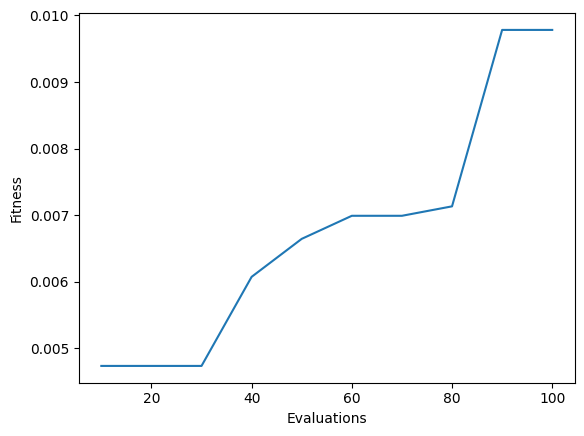

0.0097830498899244

In [164]:
config = {
    "env_name": "Walker-v0",
    "robot": walker,
    "generations": 10, # to change: increase!
    "lambda": 10, # Population size
    "mu": 5, # Parents pop size
    "sigma": 0.1, # mutation std
    "lr": 1, # Learning rate
    "max_steps": 100, # to change to 500
}

a = ES(config)
a.fitness

In [165]:
env = make_env(config["env_name"], robot=config["robot"])
reward, obs_list = evaluate(a, env, render=False)
env.close()

In [166]:
np.save("Walker.npy", a.genes)

## Pre-trained walker

In [167]:
# load weights

config = {
    "env_name": "Walker-v0",
    "robot": walker,
    "generations": 100,
    "lambda": 10, # Population size
    "mu": 5, # Parents pop size
    "sigma": 0.1, # mutation std
    "lr": 1, # Learning rate
    "max_steps": 500,
}

cfg = get_cfg(config["env_name"], robot=config["robot"]) # Get network dims
cfg = {**config, **cfg} # Merge configs
a = Agent(Network, cfg)
a.genes = np.load("Walker.npy")

In [168]:
env = make_env(cfg["env_name"], robot=cfg["robot"])
a.fitness, _ = evaluate(a, env, render=False)
env.close()
print(a.fitness)

0.020206844612997765


In [169]:
import json
def save_solution(a, cfg, name="solution.json"):
    save_cfg = {}
    for i in ["env_name", "robot", "n_in", "h_size", "n_out"]:
        assert i in cfg, f"{i} not in config"
        save_cfg[i] = cfg[i]
    save_cfg["robot"] = cfg["robot"].tolist()
    save_cfg["genes"] = a.genes.tolist()
    save_cfg["fitness"] = float(a.fitness)
    # save
    with open(name, "w") as f:
        json.dump(save_cfg, f)
    return save_cfg

In [170]:
save_solution(a, cfg)

{'env_name': 'Walker-v0',
 'robot': [[3, 3, 3, 3, 3],
  [3, 3, 3, 3, 3],
  [3, 0, 0, 0, 3],
  [3, 0, 0, 0, 3],
  [3, 0, 0, 0, 3]],
 'n_in': 62,
 'h_size': 32,
 'n_out': 16,
 'genes': [0.029893528152902624,
  0.0649567973920539,
  0.23825425708192507,
  0.13018370014069913,
  -0.008760075433138559,
  -0.08680670193983932,
  -0.10914767931388976,
  -0.23062340231740824,
  0.08089904008410297,
  0.25695657782360176,
  -0.23812722516222817,
  0.026538148579743133,
  -0.36754686677480664,
  0.01366307218661085,
  -0.06416245768749168,
  0.127767867222626,
  0.11665883865960536,
  0.09810159575506734,
  -0.16534660080779418,
  -0.3115011629301359,
  -0.02484613170560874,
  0.06463971253546187,
  -0.11880316937748336,
  -0.07873026753257449,
  -0.03947382131672984,
  0.19995643500365673,
  0.12120753684822366,
  0.13099931600852693,
  0.24706458724033548,
  -0.2845180257593529,
  0.1499257123637401,
  -0.5574148543961738,
  0.1878205439850172,
  0.13376232462093185,
  0.23870931054848166,
  -

In [171]:
def load_solution(name="solution.json"):
    with open(name, "r") as f:
        cfg = json.load(f)
    cfg["robot"] = np.array(cfg["robot"])
    cfg["genes"] = np.array(cfg["genes"])
    a = Agent(Network, cfg, genes=cfg["genes"])
    a.fitness = cfg["fitness"]
    return a

0.020206844612997765
[[ 0.          0.         -0.25       ... -0.28       -0.28
  -0.28      ]
 [ 0.04852173  0.41078848 -0.2303882  ... -0.28060248 -0.28052453
  -0.28005368]
 [ 0.04362808  0.57552156 -0.20793235 ... -0.28194494 -0.28205187
  -0.28038143]
 ...
 [ 0.01098152  0.01939606 -0.18080579 ... -0.29207193 -0.29187566
  -0.29169845]
 [ 0.01004583  0.07644962 -0.18083523 ... -0.29190097 -0.29210227
  -0.29192838]
 [ 0.01010192 -0.00675888 -0.18086615 ... -0.29191157 -0.29195928
  -0.29216594]]


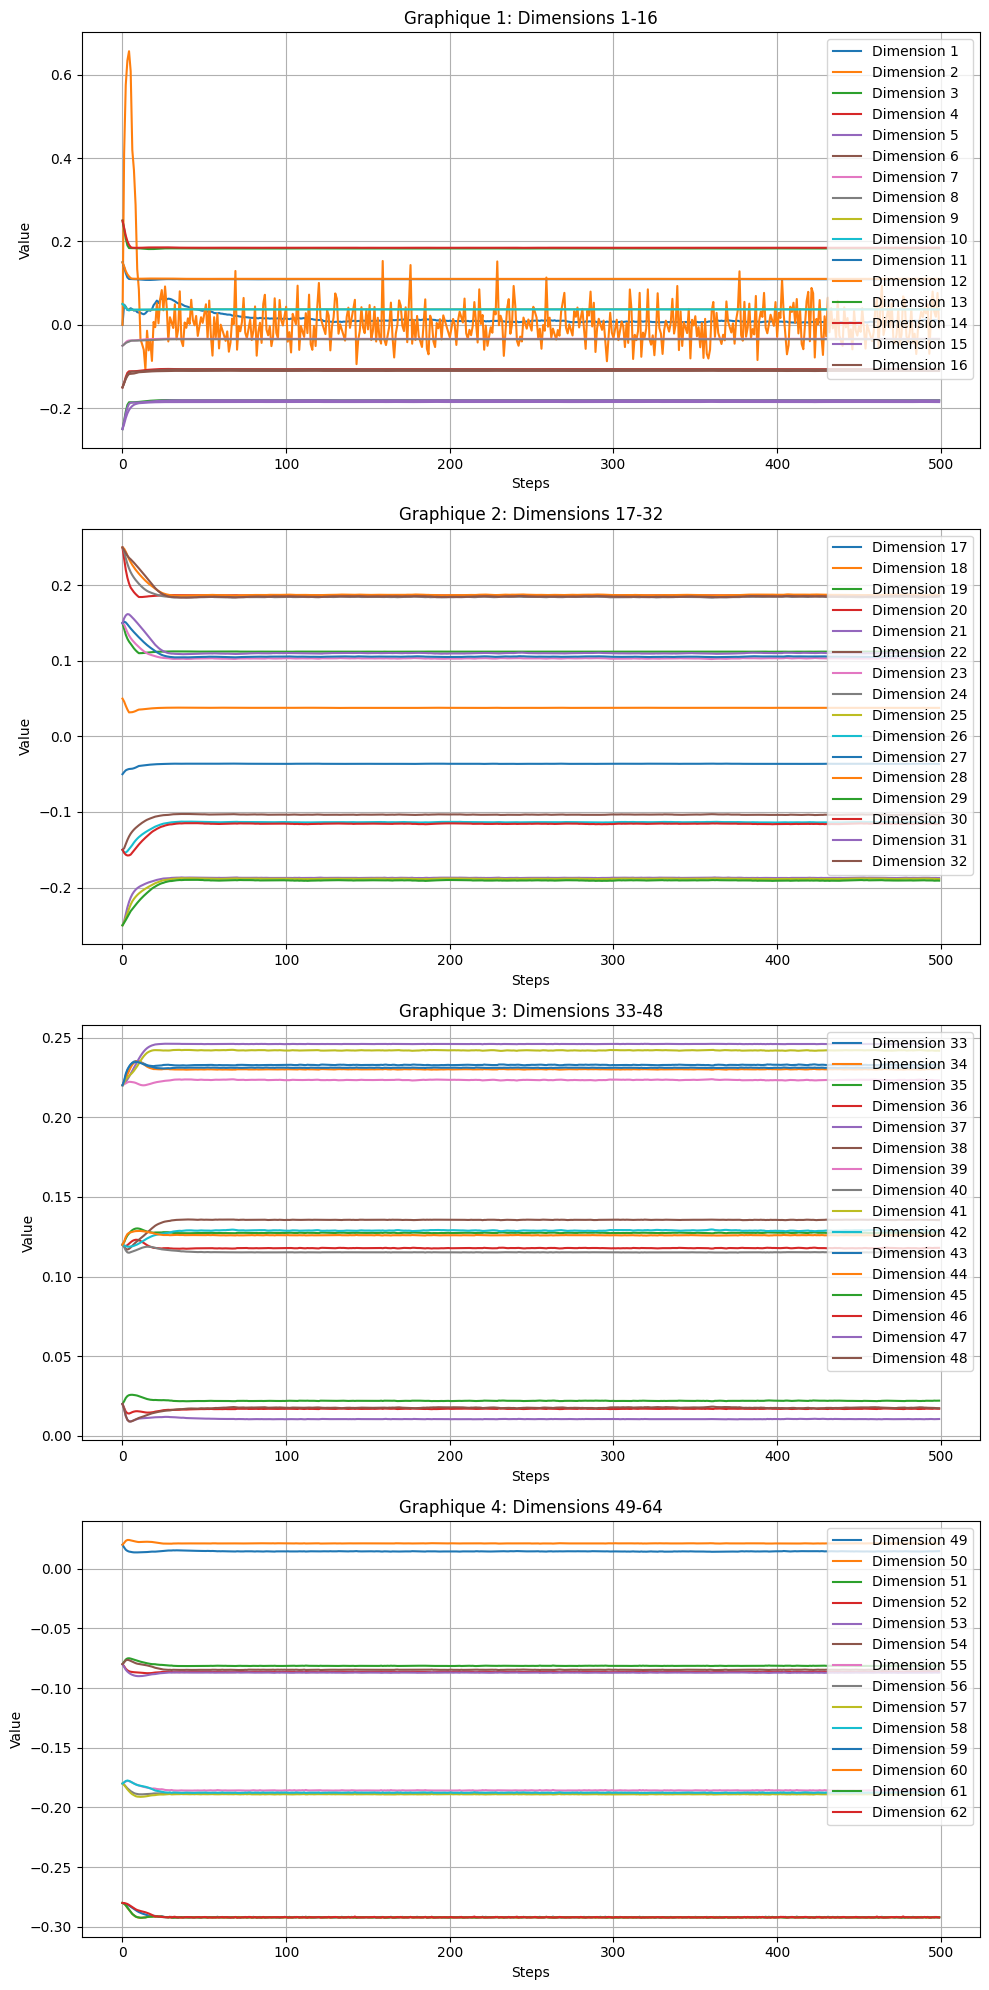

In [172]:
a = load_solution(name="solution.json")
cfg = a.config
env = make_env(cfg["env_name"], robot=cfg["robot"])
a.fitness,obs_list = evaluate(a, env, render=False)
env.close()
print(a.fitness)

print(obs_list)

fig, axes = plt.subplots(4, 1, figsize=(10, 20))
axes = axes.flatten()

for i in range(4):
    for j in range(16):
        dim_index = i * 16 + j  
        if dim_index < 62:  
            axes[i].plot(obs_list[:, dim_index], label=f"Dimension {dim_index+1}")

    axes[i].set_title(f"Graphique {i+1}: Dimensions {i*16+1}-{(i+1)*16}")
    axes[i].set_xlabel('Steps')
    axes[i].set_ylabel('Value')
    axes[i].legend(loc='upper right')
    axes[i].grid(True)

plt.tight_layout()
plt.show()